# Task 2: CNN Training for pixel-wise classification

In this task you will be provided a model that was pretrained on [BigEarthNet v2](https://arxiv.org/abs/1902.06148) for pixel-wise classification (i.e. semantic segmentation). We will provide you with a checkpoint, as well as the model definition and your task is to load that model using these weights and finetune it on our target domain (forest segmentation) in our target location (Amazon Rainforest) with pytorch lightning. For that we will provide you with a finetuning dataset.

<img src="../../../data/Example_finetune.png" alt="Example from Dataset" width="600"/>


The goals of this task are as follows:
1. Load a pretrained pixelwise segmentation model
2. Adapt and finetune the model on a new domain (forest segmentation) and location (Amazon Rain Forest)

## Imports

These are all imports we used when solving the task. Please leave them as is even though you might not need all of them.

In [1]:
import os
import rootutils
root = rootutils.setup_root(os.path.abspath(''), dotenv=True, pythonpath=True, cwd=False)

data_path = root / "data"
data_path.mkdir(exist_ok=True)
output_dir = root / "output"
output_dir.mkdir(exist_ok=True)


In [2]:
import torch
from types import SimpleNamespace
from huggingface_hub import PyTorchModelHubMixin
import lightning as L
from configilm import ConfigILM # see https://lhackel-tub.github.io/ConfigILM/ for more information
from torchinfo import summary

from torchmetrics.segmentation import MeanIoU
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as VF

import lmdb
from torch.utils.data import Dataset, DataLoader, random_split
from safetensors.numpy import load as load_np_safetensor
import torchvision.transforms as transforms

from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import random

from lightning.pytorch import Trainer
from torch.utils.data import Subset
import numpy as np

In [3]:
# Additionally, import util functions that where copied from the lab notebooks
import labUtils as labUtils

## 2.1 Dataset + DataModule definition

Before we can use our data we need to wrap it in a pytorch dataset and thereafter in a lightning DataModule so we can use it for model training. 

### Dataset

For efficient data loading we have put the images in the file `images.lmdb` and the segmentation masks (forest/ no forest) in the file `mask.lmdb`. [LMDB](http://www.lmdb.tech/doc/) is a key-value in-memory database. For the images the key is the image name (1.tif, 2.tif,...) and the values are the image pixels as safetensor (Tip: use `load_np_safetensor` to read it). For the masks the key is the image name followed by _mask (1_mask.tif, 2_mask.tif, ...) the value again is the pixels as safetensor (1 for forest, 0 for no forest). We provided the helper function `_open_lmdb` which opens a connection to the lmdb for images or masks if it does not exist yet. You can read data from the lmdb through `with self.env_images.begin() as txn: txn.get()`. Feel free to add additional functions and adapt the already existing ones. Please open the lmdb only in the `__getitem__` method, due to multi processing.
Use preprocessing and data augmentation where applicable.

In [35]:
global_mean = torch.tensor([438.37207031, 614.05566406, 588.40960693, 2193.29199219, 942.84332275, 1769.93164062, 2049.55151367, 1568.22680664, 997.73248291, 2235.55664062])
global_std  = torch.tensor([607.02685547, 603.29681396, 684.56884766, 1369.3717041, 738.43267822, 1100.45605469, 1275.80541992, 1070.16125488, 813.52764893, 1356.54406738])

def normalize_s2_image(image_tensor):
    mean = global_mean
    std  = global_std
    return (image_tensor - mean[:, None, None]) / std[:, None, None]
    

def denormalize_s2_image(norm_tensor):
    mean = global_mean
    std  = global_std
    return norm_tensor * std[:, None, None] + mean[:, None, None]


# ------------------------
# Data Augmentation
def random_crop(image, mask, new_size=96, target_size=120):
    _, h, w = image.shape
    top = random.randint(0, h - new_size)
    left = random.randint(0, w - new_size)

    image = image[:, top:top+new_size, left:left+new_size]
    mask = mask[:, top:top+new_size, left:left+new_size]

    image = VF.resize(image, [target_size, target_size])
    # I interpolate NEAREST here because the mask needs to stay binary
    mask = VF.resize(mask, [target_size, target_size], interpolation=transforms.InterpolationMode.NEAREST)
    return image, mask

class PairedTransform:
    def __init__(self, flip=True, noise=True, brightness=True, crop=True):
        self.flip = flip
        self.noise = noise
        self.brightness = brightness
        self.crop = crop

    def __call__(self, image, mask):
        if self.flip and random.random() > 0.5:
            image = VF.hflip(image)
            mask = VF.hflip(mask)

        if self.flip and random.random() > 0.5:
            image = VF.vflip(image)
            mask = VF.vflip(mask)

        if self.crop and random.random() > 0.5:
            image, mask = random_crop(image, mask)

        # Augmentations that only affect the image
        if self.brightness and random.random() > 0.5:
            factor = random.uniform(0.8, 1.2)
            image = image * factor

        if self.noise and random.random() > 0.5:
            noise = torch.randn_like(image) * 0.05
            image = image + noise

        return image, mask
    
transform = PairedTransform()


# --------------------------
# The actual dataset

class FinetuneDataset(Dataset):
    def __init__(self, images_lmdb_path=data_path / "images.lmdb", masks_lmdb_path=data_path / "mask.lmdb", transform=None):
        self.images_lmdb_path = images_lmdb_path
        self.masks_lmdb_path = masks_lmdb_path

        self.transform = transform

        self.env_images = self._open_lmdb(None, str(self.images_lmdb_path))
        self.env_masks = self._open_lmdb(None, str(self.masks_lmdb_path))

        with self.env_images.begin() as txn:
            self.length = txn.stat()['entries']


    def _open_lmdb(self, env, path):
        # If the environment is already opened, simply return it
        if env is not None:
            return env
    
        # The path must be a nonempty string
        if not path:
            raise ValueError("The LMDB path is not set")
    
        # Attempt to open the environment; if it fails, rewrap the exception
        try:
            return lmdb.open(path, readonly=True, lock=False)
        except lmdb.Error as e:
            raise RuntimeError(f"Failed to open LMDB at {path!r}") from e


    def _get_image_keys(self):
        with self.env_images.begin() as txn:
            cursor = txn.cursor()
            return [key.decode() for key, _ in cursor]
        
    
    def _get_mask_keys(self):
        with self.env_masks.begin() as txn:
            cursor = txn.cursor()
            return [key.decode() for key, _ in cursor]
        

    def __len__(self):
        return self.length


    def __getitem__(self, idx):
        key_image = str(f"{idx}.tif").encode()
        key_mask = str(f"{idx}_mask.tif").encode()

        with self.env_images.begin() as img_txn:
            img_bytes = img_txn.get(key_image)
            if img_bytes is None:
                raise KeyError(f"Image not found at index {idx}")
            image = load_np_safetensor(img_bytes)["data"]

        with self.env_masks.begin() as mask_txn:
            mask_bytes = mask_txn.get(key_mask)
            if mask_bytes is None:
                raise KeyError(f"Mask not found at index {idx}")
            mask = load_np_safetensor(mask_bytes)["data"]

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)      

        if self.transform:
            image, mask = self.transform(image, mask)

        image = normalize_s2_image(image)
        return image, mask

dataset has length of: 5852


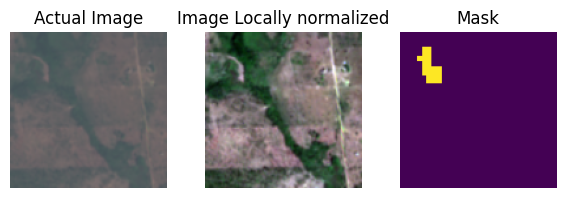

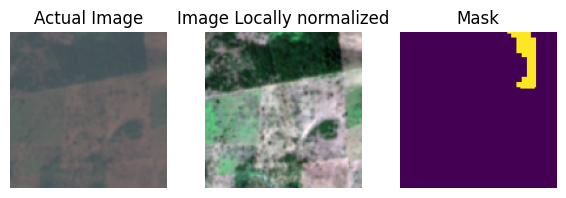

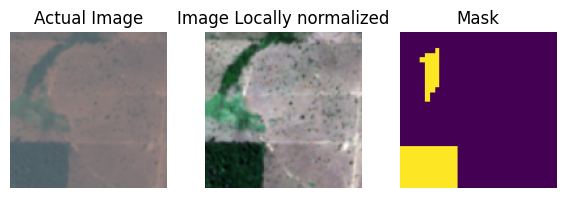

In [36]:
# Util plot function
def show_image_and_mask(image, mask):
    rgb = denormalize_s2_image(image)
    rgb = rgb[np.array((2, 1, 0))] / 5000
    rgb = torch.clamp(rgb, 0, 1)
    rgb = rgb.permute(1, 2, 0).cpu()
    
    plt.figure(figsize=(6, 2))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("Actual Image")
    plt.axis("off")

    rgb_arr = image.cpu().numpy()
    rgb_arr = rgb_arr[np.array((2, 1, 0))] 
    rgb_arr =  np.transpose(rgb_arr, (1, 2, 0))

    plt.subplot(1, 3, 2)
    plt.imshow(labUtils.normalize_rgb(rgb_arr))
    plt.title("Image Locally normalized")
    plt.axis("off")

    mask = mask.cpu().numpy().squeeze()

    plt.subplot(1, 3, 3)
    plt.imshow(mask, cmap="viridis", vmin=0, vmax=1)
    plt.title("Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# ------------------
# Testing the Dataset 

dataset = FinetuneDataset(
    images_lmdb_path = data_path / "images.lmdb",
    masks_lmdb_path = data_path / "mask.lmdb",
    transform=transform,
)

#print(dataset._get_image_keys())

print(f"dataset has length of: {dataset.length}")

# inspecting the dataset a little bit
# note for myself: good example idx = 120

def show_random_image():
    idx = random.randrange(0, dataset.length)
    image, mask = dataset[idx]
    # check normalization
    #print("Image value ranges")
    #print(image.min().item(), image.max().item(), image.mean().item(), image.std().item())
    #print("Mask value ranges")
    #print(mask.min().item(), mask.max().item(), mask.mean().item(), mask.std().item())
    show_image_and_mask(image, mask)

for i in range(3):
    show_random_image()

### DataModule

Your DataModule needs to return a valid dataloader for training, validation and testing. Implement the [pytorch lighting](https://lightning.ai/docs/pytorch/stable/) training procedure.

In [48]:
class FinetuneDataModule(L.LightningDataModule):
    def __init__(
        self,
        images_lmdb_path= data_path / "images.lmdb",
        masks_lmdb_path= data_path / "mask.lmdb",
        batch_size=8,
        num_workers=0,
        transform=transform,
    ):
        super().__init__()
        self.images_lmdb_path = images_lmdb_path
        self.masks_lmdb_path = masks_lmdb_path
        self.batch_size = batch_size
        self.num_workers = num_workers
        transform=transform,

    def setup(self, stage=None):
        full_dataset = FinetuneDataset(
            images_lmdb_path=self.images_lmdb_path,
            masks_lmdb_path=self.masks_lmdb_path,
            transform=transform,
        )

        # Shuffle indices
        indices = list(range(len(full_dataset)))
        #random.seed(25)
        random.shuffle(indices)

        # ATM I split the dataset fixed into train 80%, val 15% and test 5%
        train_end = int(0.8 * len(indices))
        val_end = int(0.95 * len(indices))

        self.train_set = Subset(full_dataset, indices[:train_end])
        self.val_set = Subset(full_dataset, indices[train_end:val_end])
        self.test_set = Subset(full_dataset, indices[val_end:])

        print("--- dataloader overview ---")
        print(f"len train set: {len(self.train_set)}")
        print(f"len val set: {len(self.val_set)}")
        print(f"len test set: {len(self.test_set)}")


    def train_dataloader(self):
        return DataLoader(self.train_set, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.val_set, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.test_set, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

In [49]:
# ----------------------------
# initialyzing the data module

dm = FinetuneDataModule(
    images_lmdb_path=data_path / "images.lmdb",
    masks_lmdb_path=data_path / "mask.lmdb",
    batch_size=8,
    num_workers=0,
    transform=transform,
)
dm.setup()

--- dataloader overview ---
len train set: 4681
len val set: 878
len test set: 293


In [50]:
# ---------------------
# Dataset analysis

# My model did perform very bad initially, so I checked the dataset that I created a little more

def check_dataset_balance(dataset, name, threshold=0.01):
    total_pixels = 0
    total_forested = 0
    mostly_empty = 0

    for i in range(len(dataset)):
        _, mask = dataset[i]
        mask = mask.numpy()

        if mask.ndim == 3:
            mask = mask.squeeze() 

        num_pixels = mask.size
        num_forested = np.sum(mask)

        total_pixels += num_pixels
        total_forested += num_forested

        forest_ratio = num_forested / num_pixels
        if forest_ratio < threshold:
            mostly_empty += 1

    ratio = total_forested / total_pixels
    print(f"{name} set balance:")
    print(f" - Total forest pixels: {total_forested}")
    print(f" - Total pixels: {total_pixels}")
    print(f" - Overall forest ratio: {ratio:.4f}")
    print(f" - Images with <{int(threshold*100)}% forest: {mostly_empty}/{len(dataset)}")


check_dataset_balance(dm.train_set, "train")
check_dataset_balance(dm.val_set, "val")
check_dataset_balance(dm.test_set, "test")

train set balance:
 - Total forest pixels: 32694078.0
 - Total pixels: 67406400
 - Overall forest ratio: 0.4850
 - Images with <1% forest: 680/4681
val set balance:
 - Total forest pixels: 6270948.0
 - Total pixels: 12643200
 - Overall forest ratio: 0.4960
 - Images with <1% forest: 116/878
test set balance:
 - Total forest pixels: 2146316.0
 - Total pixels: 4219200
 - Overall forest ratio: 0.5087
 - Images with <1% forest: 49/293


## 2.2 Model Definition

In the following we provide you with the definition for a pretrained Resnet18 (pretrained on BigEarthNet). After we have given you an adaptation of the architecture to be used for semantic segmentation. You need to complete the rest of the required model setup.

### BEN pretrained Resnet18

Here we provide you with the definition of a Resnet18 model pretrained on BEN.

In [51]:
class Resnet(L.LightningModule, PyTorchModelHubMixin):
    def __init__(self, config):
        super().__init__()
        self.config = SimpleNamespace(**config)
        self.model = ConfigILM.ConfigILM(self.config)

    def forward(self, x):
        return self.model(x)

### Fully convolutional adaptation

We have only defined the bare minimum (architecture + forward pass). You need to fill in the rest and add functions were appropriate so the model can be used for training later on. As evaluation metric you can use mean Intersection over Union (mIoU). Have a look at [mIoU](https://lightning.ai/docs/torchmetrics/stable/segmentation/mean_iou.html) imported above. Implement the [pytorch lighting](https://lightning.ai/docs/pytorch/stable/) training steps.

In [54]:
pretrained_model  = Resnet.from_pretrained("BIFOLD-BigEarthNetv2-0/resnet18-s2-v0.2.0").model.vision_encoder
backbone = nn.Sequential(*list(pretrained_model.children())[:-2])

# will be used later on
# code source: https://medium.com/data-scientists-diary/implementation-of-dice-loss-vision-pytorch-7eef1e438f68
class DiceLoss:
    def __init__(self, smooth=1):
        self.smooth = smooth
    
    def __call__(self, probs, target):
        intersection = (probs * target).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


# ---------------------
# My actual model

class FCNResnet(L.LightningModule):
    def __init__(self, num_classes=2, learning_rate=1e-4):
        
        # Note: 
        # Initially i chose num_classes = 1 since it's a binary prediction
        # But than i saw that the backup_model has 2 output channels so i adapted mine accordingly

        super().__init__()
        self.learning_rate = learning_rate
        self.num_classes = num_classes

        self.loss_ce = nn.CrossEntropyLoss()
        self.loss_di = DiceLoss()
        self.mIoU = MeanIoU(num_classes=num_classes) #used for val and test

        self.val_outputs = []
        self.test_outputs = []

        self.backbone = backbone

        # Freezeing for Fine Tuning
        for layer in self.backbone:
            for param in layer.parameters():
                param.requires_grad = False

        # Decoder layers
        # note: they are defined each as a own variable here so i can individually use them in my forward pass to use skip connections

        dropout_rate = 0.2

        self.dec1 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
        )
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

        self.dec2 = nn.Sequential(
            nn.Conv2d(256 + 256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
        )
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

        self.dec3 = nn.Sequential(
            nn.Conv2d(128 + 128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
        )
        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

        self.dec4 = nn.Sequential(
            nn.Conv2d(64 + 64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
        )
        self.up4 = nn.Upsample(size=(120, 120), mode='bilinear', align_corners=False)

        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1)


    def get_loss(self, preds, masks):
        ce_loss = self.loss_ce(preds, masks.squeeze(1).long())

        # Also use L1 and Dice loss
        # I added this to help the model understand structural patterns better
        probs = torch.softmax(preds, dim=1)
        forest_probs = probs[:, 1:2, :, :]
        forest_target = (masks == 1).float()

        l1_loss = F.l1_loss(forest_probs, forest_target)
        dice_loss = self.loss_di(forest_probs, forest_target)

        return 0.4 * ce_loss + 0.3 * l1_loss + 0.3 * dice_loss


    def forward(self, x):
        # Extract intermediate features
        x = self.backbone[0](x)
        x = self.backbone[1](x)
        x = self.backbone[2](x)
        x = self.backbone[3](x)

        l1 = self.backbone[4](x)
        l2 = self.backbone[5](l1)
        l3 = self.backbone[6](l2)
        l4 = self.backbone[7](l3)

        # Decoder with skip connections
        x = self.dec1(l4)
        # The interpolation has to be done because the conv layers in resent seem to have a padding
        # which gives me one missing pixel per skip
        x = F.interpolate(x, size=l3.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, l3], dim=1)

        x = self.dec2(x)
        x = F.interpolate(x, size=l2.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, l2], dim=1)

        x = self.dec3(x)
        x = F.interpolate(x, size=l1.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, l1], dim=1)

        x = self.dec4(x)
        x = F.interpolate(x, size=(120, 120), mode='bilinear', align_corners=False)
        x = self.final_conv(x)

        return x


    def training_step(self, batch, batch_idx):
        images, masks = batch
        preds = self(images)
        loss = self.get_loss(preds, masks)
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        # For debugging
        #if batch_idx == 0:
        #    print(f"Train step output shape: {preds.shape}, mask shape: {masks.shape}")
        #    print(f"Train Loss: {loss.item()}")
        return loss


    def validation_step(self, batch, batch_idx):
        images, masks = batch
        preds = self(images)
        loss = self.get_loss(preds, masks)

        # I use the IoU only for validation and test because it's better intepretable/real worldish but not differentiable
        masks_class = masks.long().squeeze(1)
        preds_class = torch.argmax(preds, dim=1)  # shape [B, H, W]
        self.mIoU.update(preds_class, masks_class)
        
        self.log("val_loss", loss, prog_bar=True)
        return {"val_loss": loss}


    def test_step(self, batch, batch_idx):
        images, masks = batch
        preds = self(images)
        masks_class = masks.long().squeeze(1)
        preds_class = torch.argmax(preds, dim=1)  # shape [B, H, W]
        self.mIoU.update(preds_class, masks_class)
        return {}


    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer


    def on_validation_epoch_end(self):
        val_miou = self.mIoU.compute()
        self.log("val_mIoU", val_miou)
        #print(f"Epoch {self.current_epoch} done. val_mIoU = {val_miou:.4f}")
        self.mIoU.reset()


    def on_test_epoch_end(self):
        test_miou = self.mIoU.compute()
        self.log("test_mIoU", test_miou)
        self.mIoU.reset()

## 2.3 Finetuning

Please write the logic required for finetuning the model using the DataModule you have defined above. The checkpoint is the one provided by us finetuned on segmentation for BigEarthNet. Adapt the model if necessary. Briefly describe the results.


In [56]:
#ckpt_path = data_path / "pretrained_model.ckpt"

# The actual Model
model = FCNResnet(num_classes=2, learning_rate=1e-4)

# Setup logging and checkpoint saving
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="best-model-{epoch:02d}-{val_loss:.3f}"
)

early_stop_callback = EarlyStopping(
    monitor="val_loss",
    patience=4,
    mode="min",
    verbose=True,
)

trainer = Trainer(
    max_epochs=10,
    callbacks=[checkpoint_callback, early_stop_callback],
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
)

# ---------------
# Train the model
trainer.fit(model, datamodule=dm)

# -----------------
# Save the model
scripted_model = torch.jit.script(model)
scripted_model.save(root / "data/fcresnet_ehrenhoefer_v8_skipconnections.pt")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name       | Type             | Params | Mode 
---------------------------------------------------------
0  | loss_ce    | CrossEntropyLoss | 0      | train
1  | mIoU       | MeanIoU          | 0      | train
2  | backbone   | Sequential       | 11.2 M | train
3  | dec1       | Sequential       | 1.2 M  | train
4  | up1        | Upsample         | 0      | train
5  | dec2       | Sequential       | 590 K  | train
6  | up2        | Upsample         | 0      | train
7  | dec3       | Sequential       | 147 K  | train
8  | up3        | Upsample         | 0      | train
9  | dec4       | Sequential       | 37.0 K | train
10 | up4        | Upsample         | 0      | train
11 | final_conv | Conv2d           | 66     | train
---------------------------------------------------------
2.0 M     Trainable params
11.2 M    Non-trainable params
13.2 M    Total params
52.615    Total

--- dataloader overview ---
len train set: 4681
len val set: 878
len test set: 293


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.228


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


**Result Description:**

To the provided "base code" of the decoder I added batch normalization, skip connections  and dropouts.

As i will describe later-on, I added the skip connection because the masks looked to generalized and "blured". The skip connections help the decoder to keep detail of the encodings from the encoder which turned out to give me more detailed and exact masks.

I also added dropout layer because my model tended to overfit at the beginning.

As a loss function, at the beginning I had only used the typical Cross Entropy Loss. I than extended this with L1, to take structural informations into account as well as the dice loss, which promises to gives me a better controlling of the actual overlap and edges of the masks. 

## 2.4 Training Visualization + Evaluation

It is always good to visualize your training and some qualitative examples on top of the quantitative results obtained above. In this task you should:
1. Visualize model performance over the training epochs
2. Visualize some examples.

Briefly describe the results.

### 2.4.1 Training Visualization

Please visualize validation loss as well as validation performance over the epochs of your training. We recommend using the lighting `CSVLogger`. Plot the results.

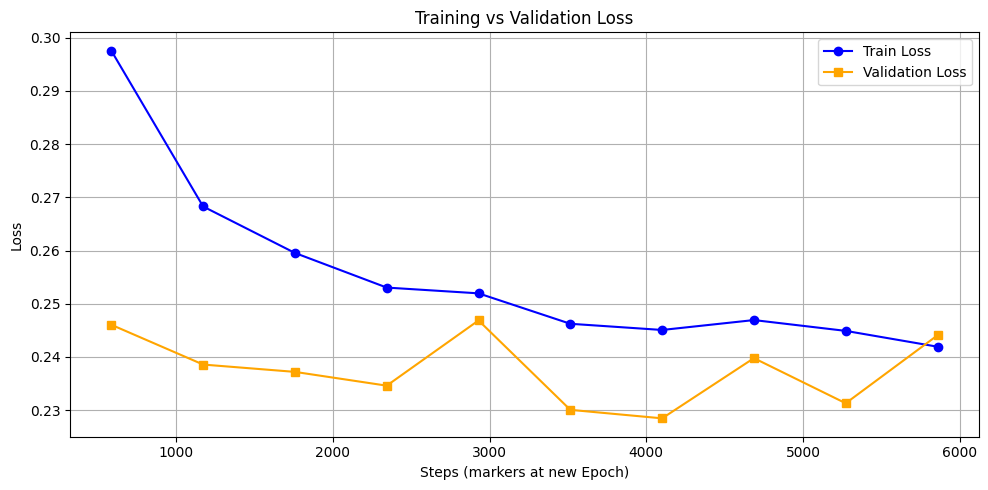

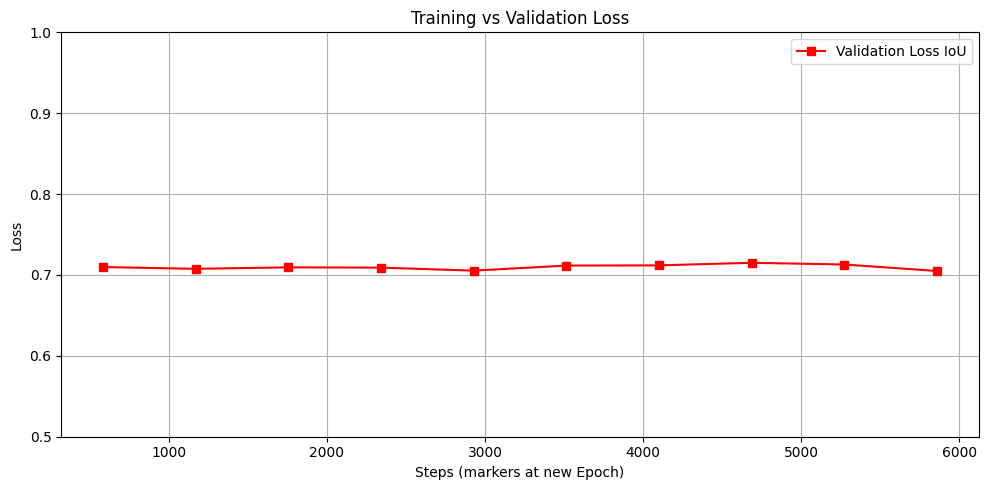

In [57]:
from tensorboard.backend.event_processing import event_accumulator

event_path = "lightning_logs/version_30/events.out.tfevents.1753435282.THINKPAD.14104.6"

ea = event_accumulator.EventAccumulator(event_path)
ea.Reload()

# get the logged loss data from the training
train_loss_events = ea.Scalars("train_loss")
val_loss_events = ea.Scalars("val_loss")
val_iou_loss_events = ea.Scalars("val_mIoU")

# Extract steps and values
train_steps = [e.step for e in train_loss_events]
train_values = [e.value for e in train_loss_events]

val_steps = [e.step for e in val_loss_events]
val_values = [e.value for e in val_loss_events]

val_iou_steps = [e.step for e in val_iou_loss_events]
val_iou_values = [e.value for e in val_iou_loss_events]

# The cross entropy loss (train + val)
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_values, label="Train Loss", marker="o", color="blue")
plt.plot(val_steps, val_values, label="Validation Loss", marker="s", color="orange")

plt.xlabel("Steps (markers at new Epoch)")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Also show IoU Loss
plt.figure(figsize=(10, 5))
plt.plot(val_iou_steps, val_iou_values, label="Validation Loss IoU", marker="s", color="red")
plt.xlabel("Steps (markers at new Epoch)")
plt.ylabel("Loss")
plt.ylim((0.5,1))
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Result Description:**

When visualizing the train and validation loss it looks like a okay-working training.
There seems to be no overfitting. But also it's noticable that there is not a very big improvement even in the first epochs and its stopping to improve from the 3rd epoch already.

For the IoU loss unfortunately, which is not used in training but just for evaluation, I didn't reach any significant improvement at al during the epochs.

### 2.4.2 Qualitative Evaluation

Please visualize a few (at least 2) example outputs in the form: 1: Input Image 2: Reference Mask 3: Predicted Mask.


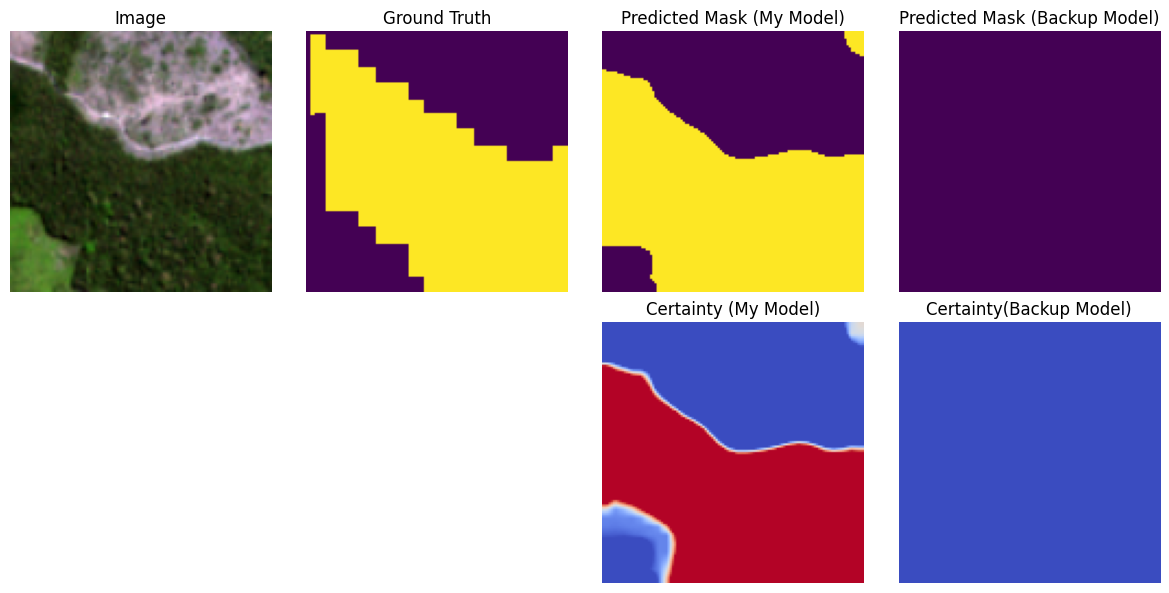

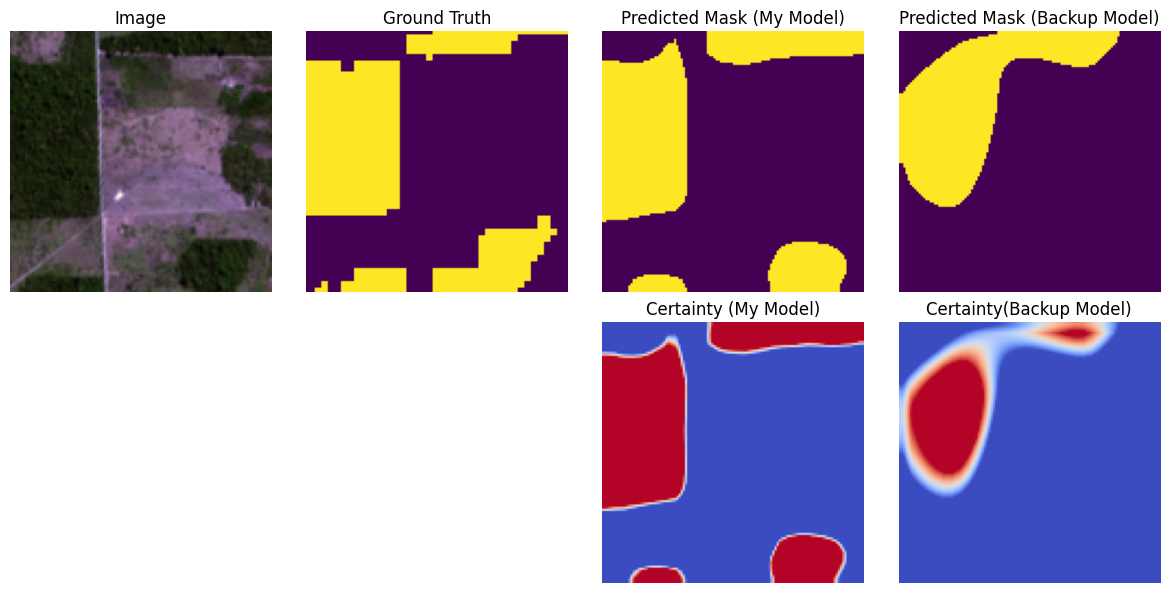

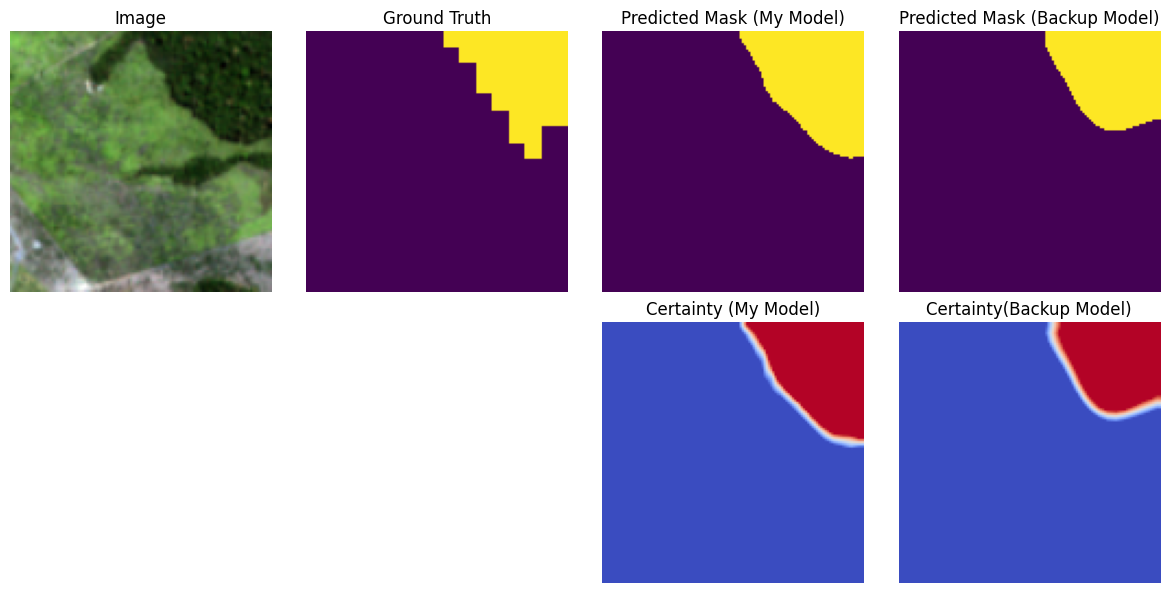

In [59]:
def show_image_mask_prediction(image, mask_gt, mask_pred_mine, certainty_mine, mask_pred_backup, certainty_backup):
    image = image.cpu().numpy()
    mask_gt = mask_gt.cpu().numpy().squeeze()
    mask_pred_mine = mask_pred_mine.cpu().numpy().squeeze()
    mask_pred_backup = mask_pred_backup.cpu().numpy().squeeze()

    rgb = image[np.array((0,1,2)), : , :]
    rgb = np.transpose(rgb, (1, 2, 0))
    rgb = labUtils.normalize_rgb(rgb)

    plt.figure(figsize=(12, 6))

    plt.subplot(2, 4, 1)
    plt.imshow(rgb)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(2, 4, 2)
    plt.imshow(mask_gt, cmap="viridis", vmin=0, vmax=1)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(2, 4, 3)
    plt.imshow(mask_pred_mine, cmap="viridis", vmin=0, vmax=1)
    plt.title("Predicted Mask (My Model)")
    plt.axis("off")

    plt.subplot(2, 4, 7)
    plt.imshow(certainty_mine, cmap="coolwarm", vmin=0, vmax=1)
    plt.title("Certainty (My Model)")
    plt.axis("off")

    plt.subplot(2, 4, 4)
    plt.imshow(mask_pred_backup, cmap="viridis", vmin=0, vmax=1)
    plt.title("Predicted Mask (Backup Model)")
    plt.axis("off")

    plt.subplot(2, 4, 8)
    plt.imshow(certainty_backup, cmap="coolwarm", vmin=0, vmax=1)
    plt.title("Certainty(Backup Model)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

def get_result_from_output(model_output):
    # argmax -> which class was preferred (non forest vs forest)
    mask_pred = torch.argmax(model_output, dim=1).squeeze(0)
    # certainty -> I subtract both classes here to see how sure the model is with it's prediction
    # I noticed that this score also is quite good to predict the mask if the prediction is not that clear
    non_forest_scores = model_output[0, 0, :, :]
    forest_scores = model_output[0, 1, :, :]
    forest_certainty = forest_scores - non_forest_scores
    return mask_pred, forest_certainty

def test_model_with_dataloader(my_model, provided_backup_model, dataloader):
    my_model.eval()
    device = my_model.device

    # One batch (batch_size x image x mask)
    data_iter = iter(dataloader)
    images, masks = next(data_iter)

    # Random index within batch
    idx = random.randint(0, images.size(0) - 1)

    image = images[idx].unsqueeze(0).to(device)
    mask_gt = masks[idx].to(device)

    # if it's an empty mask, do another one since it's boring for visualization
    if mask_gt.max() == 0:
        print("re-running the method until finding a non-empty ground truth mask")
        return test_model_with_dataloader(my_model, provided_backup_model, dataloader)

    with torch.no_grad():
        mask_mine, certainty_mine = get_result_from_output(my_model(image))
        mask_backup, certainty_backup = get_result_from_output(provided_backup_model(image))

    show_image_mask_prediction(image.squeeze(0), mask_gt, mask_mine, certainty_mine, mask_backup, certainty_backup)


# -----------------------
# show the model in action
# note: I also put the backup_model here to have a comparison if my model works in a simlar way

provided_backup_model = torch.jit.load(root / "data/backup_model.pt")
provided_backup_model.eval() 

train_loader = dm.train_dataloader()
test_model_with_dataloader(model, provided_backup_model, train_loader)

val_loader = dm.val_dataloader()
test_model_with_dataloader(model, provided_backup_model, val_loader)

test_loader = dm.test_dataloader()
test_model_with_dataloader(model, provided_backup_model, test_loader)

**Result Description:**

I had a lot of issues training the model first but I think i finally reached good results.

In the plot above I am visualizing prediction examples from the dataset of my own model as well as the backup model as a comparison.

When viewing both models side to side it visually looks like my model has a decent performance.

With the ground mask images i noticed that it seems that they are not 100% accurate, which - i think - makes a perfect model hard to reach here.
When evaluating my first model versions i noticed, that the model always returned "fluid" looking big non-detailed shapes, so I added skip connections to maintain detail troughout the decoding process, which made a significant improvement.

Also I noticed that calculating what I interpreat as the certainty (class 1 - class 2) returns a very good result and seems to be way more robust, especially with new data, than just taking the max class value. This get's more obvious in the following task_3.